In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('ratings_long.csv')

r = np.full((20, 1000), fill_value=np.nan)

for rec in df.itertuples():
    r[rec.userId][rec.movieId] = rec.rating

In [14]:
def loss_fn(r, r_hat, mask, u, v, lamb):
    mse  = np.mean((r[mask] - r_hat[mask]) ** 2)
    # regularization overfitting onlemek icin L2 kullandim,loss azaliyordu o yuzden gradient descent calisti
    reg  = lamb * (np.sum(u ** 2) + np.sum(v ** 2))
    return mse + reg

np.random.seed(50)

u = np.random.random((20, 4))
v = np.random.random((4, 1000))

mask    = ~np.isnan(r) # daha dogru sonuc icin preprocessing, nan cikardim
lr      = 0.001
lamb    = 0.01
n_epoch = 1000

loss_history = []


for i in range(n_epoch):
    r_hat = u @ v
    err = np.zeros((20, 1000))
    err[mask] = r_hat[mask] - r[mask]


    g_u = err @ v.T + 2 * lamb * u
    g_v = u.T @ err + 2 * lamb * v

    g_norm = np.linalg.norm(g_u) + np.linalg.norm(g_v)
    l      = loss_fn(r, r_hat, mask, u, v, lamb)
    loss_history.append(l)

    if i % 100 == 0:
        print(f"epoch {i:4d}  {g_norm:.4f}  {l:.4f}")


    u -= lr * g_u
    v -= lr * g_v

print(f"\nloss: {loss_fn(r, r_hat, mask, u, v, lamb):.4f}")

epoch    0  135.6698  19.6543
epoch  100  53.7093  16.2215
epoch  200  22.9113  15.9242
epoch  300  12.8791  15.8383
epoch  400  8.7095  15.7880
epoch  500  6.6913  15.7465
epoch  600  5.6240  15.7075
epoch  700  4.9082  15.6696
epoch  800  4.2494  15.6322
epoch  900  3.5808  15.5950

loss: 15.5575


In [65]:
r_hat = u @ v
print("tahmin matrisi:", r_hat.shape)

print("\nornek tahminler :\n", np.round(r_hat[:5, :10], 2))

print("\nmin :", np.min(r_hat))
print("max :", np.max(r_hat))
print("mean:", np.mean(r_hat))

tahmin matrisi: (20, 1000)

ornek tahminler :
 [[2.51 1.83 2.61 1.72 3.06 3.01 2.97 3.26 1.09 3.18]
 [3.39 1.73 2.75 2.08 3.31 2.85 3.5  3.71 1.   3.64]
 [3.13 2.5  2.79 1.8  3.5  3.25 3.69 3.61 1.31 4.06]
 [3.63 2.1  2.86 2.03 3.11 2.63 3.43 3.32 1.03 3.79]
 [2.76 1.85 2.21 1.51 2.58 2.23 2.84 2.7  0.91 3.15]]

min : 0.1547532365837565
max : 6.7723415051457785
mean: 2.557932760111746


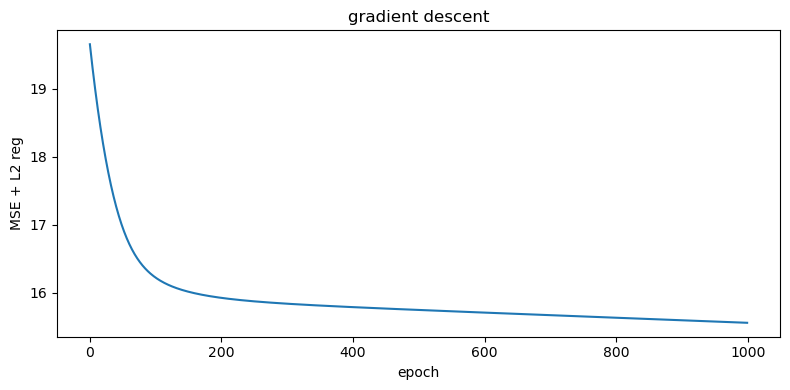

In [16]:
#daha iyi gorebilmek icin derste ogrendigimiz loss curve grafigi ekledim

plt.figure(figsize=(8, 4))
plt.plot(loss_history)
plt.xlabel("epoch")
plt.ylabel("MSE + L2 reg")
plt.title("gradient descent")
plt.tight_layout()
plt.show()

In [18]:
# pred matris (MSE/RMSE kullandim)
r_hat = u @ v

print("r_hat shape:", r_hat.shape)
print(np.round(r_hat[:5, :10], 2))

r_hat shape: (20, 1000)
[[2.51 1.83 2.61 1.72 3.06 3.01 2.97 3.26 1.09 3.18]
 [3.39 1.73 2.75 2.08 3.31 2.85 3.5  3.71 1.   3.64]
 [3.13 2.5  2.79 1.8  3.5  3.25 3.69 3.61 1.31 4.06]
 [3.63 2.1  2.86 2.03 3.11 2.63 3.43 3.32 1.03 3.79]
 [2.76 1.85 2.21 1.51 2.58 2.23 2.84 2.7  0.91 3.15]]


In [19]:
# final metric
r_hat = u @ v

mse  = np.mean((r_hat[mask] - r[mask]) ** 2)
rmse = np.sqrt(mse)

print("MSE :", round(mse,  4))
print("RMSE:", round(rmse, 4))

MSE : 0.009
RMSE: 0.0949


In [20]:
# actual vs pred
rows, cols = np.where(mask)

result_rows = []
for i in range(10):
    user  = rows[i]
    movie = cols[i]
    result_rows.append({
        "user"     : user,
        "movie"    : movie,
        "actual"   : r[user, movie],
        "predicted": round(r_hat[user, movie], 2),
        "error"    : round(r_hat[user, movie] - r[user, movie], 2)
    })

pd.DataFrame(result_rows)

,user,movie,actual,predicted,error
0,0,16,5.0,4.72,-0.28
1,0,72,5.0,4.94,-0.06
2,0,86,5.0,4.95,-0.05
3,0,259,1.0,1.01,0.01
4,0,319,4.0,3.95,-0.05
5,0,521,4.0,4.01,0.01
6,0,534,2.0,2.48,0.48
7,0,671,1.0,1.05,0.05
8,0,673,2.0,1.99,-0.01
9,0,739,3.0,3.28,0.28
